In [ ]:
import os
import pandas as pd

# 设置输入输出路径
input_path = '../data/raw/sales_data.csv'
output_folder = '../data/processed'
output_file = os.path.normpath(os.path.join(output_folder, 'store_sales_split.xlsx'))

# 创建输出文件夹（如果不存在）
os.makedirs(output_folder, exist_ok=True)

# 加载原始数据
df = pd.read_csv(input_path, parse_dates=['Date'])
df['Store ID'] = df['Store ID'].astype(str)

# 获取所有门店编号
store_ids = df['Store ID'].unique()
print(f"共检测到 {len(store_ids)} 家门店：{store_ids.tolist()}")

# 创建 Excel 文件并写入多个 Sheet
with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    print("正在写入 Sheet：All Stores（原始总数据）")
    df.to_excel(writer, sheet_name='All Stores', index=False)

    for i, store_id in enumerate(store_ids, start=1):
        print(f"正在处理第 {i} 家门店：{store_id}")
        store_df = df[df['Store ID'] == store_id]
        sheet_name = f'Store {store_id}'
        store_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"✅ 所有门店数据已成功写入 Excel 文件：{output_file}")

In [ ]:
df_store_1.head()

In [1]:
# 标记促销日：占比超过阈值即为 True 
stats['Is_Promotion_Day'] = stats['Promo_Ratio'] >= 0.3 
# 可选：将布尔值转换为标签 
stats['Promotion_Day_Label'] = stats['Is_Promotion_Day'].map({True: '促销日', False: '非促销日'}) 
# 查看结果 
print(stats[['Date', 'Promo_Items', 'Promo_Ratio', 'Promotion_Day_Label']])

NameError: name 'stats' is not defined

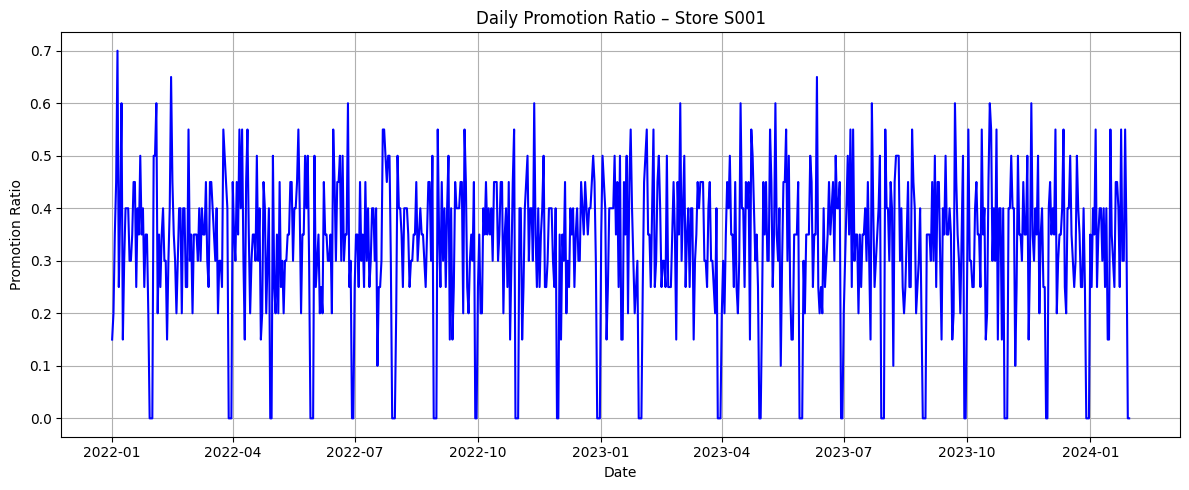

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(stats['Date'], stats['Promo_Ratio'], color='blue', linewidth=1.5)
plt.title('Daily Promotion Ratio – Store S001')
plt.xlabel('Date')
plt.ylabel('Promotion Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# 标记促销日：占比超过阈值即为 True
stats['Is_Promotion_Day'] = stats['Promo_Ratio'] >= 0.3

# 可选：将布尔值转换为标签
stats['Promotion_Day_Label'] = stats['Is_Promotion_Day'].map({True: '促销日', False: '非促销日'})

# 查看结果
print(stats[['Date', 'Promo_Items', 'Promo_Ratio', 'Promotion_Day_Label']])

          Date  Promo_Items  Promo_Ratio Promotion_Day_Label
0   2022-01-01            3         0.15                非促销日
1   2022-01-02            4         0.20                非促销日
2   2022-01-03            7         0.35                 促销日
3   2022-01-04            9         0.45                 促销日
4   2022-01-05           14         0.70                 促销日
..         ...          ...          ...                 ...
755 2024-01-26            6         0.30                 促销日
756 2024-01-27           11         0.55                 促销日
757 2024-01-28            7         0.35                 促销日
758 2024-01-29            0         0.00                非促销日
759 2024-01-30            0         0.00                非促销日

[760 rows x 4 columns]


In [13]:
# 统计促销日数量
promo_day_count = stats['Is_Promotion_Day'].sum()

# 总天数
total_days = len(stats)

# 促销日占比
promo_day_ratio = round(promo_day_count / total_days, 4)

# 输出结果
print(f"📅 总天数：{total_days}")
print(f"🔥 促销日数量：{promo_day_count}")
print(f"📊 促销日占比：{promo_day_ratio}")

📅 总天数：760
🔥 促销日数量：537
📊 促销日占比：0.7066


In [14]:
# 添加年份字段（如果 Date 已是 datetime 类型则无需转换）
stats['Year'] = stats['Date'].dt.year

# 统计 2022 年
stats_2022 = stats[stats['Year'] == 2022]
promo_day_count_2022 = stats_2022['Is_Promotion_Day'].sum()
total_days_2022 = len(stats_2022)
promo_day_ratio_2022 = round(promo_day_count_2022 / total_days_2022, 4)

# 统计 2023 年
stats_2023 = stats[stats['Year'] == 2023]
promo_day_count_2023 = stats_2023['Is_Promotion_Day'].sum()
total_days_2023 = len(stats_2023)
promo_day_ratio_2023 = round(promo_day_count_2023 / total_days_2023, 4)

# 输出结果
print(f"\n📅 2022 年总天数：{total_days_2022}")
print(f"🔥 2022 年促销日数量：{promo_day_count_2022}")
print(f"📊 2022 年促销日占比：{promo_day_ratio_2022}")

print(f"\n📅 2023 年总天数：{total_days_2023}")
print(f"🔥 2023 年促销日数量：{promo_day_count_2023}")
print(f"📊 2023 年促销日占比：{promo_day_ratio_2023}")


📅 2022 年总天数：365
🔥 2022 年促销日数量：265
📊 2022 年促销日占比：0.726

📅 2023 年总天数：365
🔥 2023 年促销日数量：251
📊 2023 年促销日占比：0.6877


In [17]:
average_promo_ratio = round((promo_day_ratio_2022 + promo_day_ratio_2023) / 2, 4)
print(f"📊 平均年促销日占比（2022–2023）：{average_promo_ratio}")

📊 平均年促销日占比（2022–2023）：0.7068
